# Authentication Log Anomaly Detection
### Clustering-Based Detection of Suspicious Access Patterns in Carrier-Scale Environments

**Author:** Eric Maurer | CISSP | Principal IAM & Security Architect  
**Methods:** K-Means Clustering · DBSCAN · PCA · Behavioral Anomaly Scoring

---

## Background

Traditional IP-based anomaly detection breaks down in large carrier or ISP environments. A single user may legitimately authenticate from dozens of IPs in a single day — internal RFC1918 ranges, CGNAT addresses, home cable circuits, VPN egress nodes, and remote management subnets spanning a national footprint.

Standard IP-reputation and geo-anomaly tools generate massive false-positive volume in this environment, training analysts to ignore alerts — the worst possible outcome.

This project demonstrates a **behavioral clustering approach** that detects genuine anomalies without being triggered by normal IP variance. The core insight: **flag behavioral inconsistency, not IP inconsistency.**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, precision_score, recall_score, f1_score, confusion_matrix
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Synthetic Data Generation

In [21]:
IP_POOLS = {
    'internal_corp':   [f'10.{r}.{s}.{h}'    for r in range(1,5)    for s in range(0,256,32) for h in [10,20,30,40,50]],
    'internal_mgmt':   [f'172.{r}.{s}.{h}'   for r in range(16,20)  for s in range(0,256,16) for h in [5,15,25]],
    'cgnat':           [f'100.{r}.{s}.{h}'   for r in range(64,96)  for s in range(0,256,8)  for h in [1,2,3]],
    'cable_customer':  [f'96.{r}.{s}.{h}'    for r in range(0,32)   for s in range(0,256,16) for h in [1,100,200]],
    'cable_customer2': [f'73.{r}.{s}.{h}'    for r in range(0,32)   for s in range(0,256,16) for h in [1,50,150]],
    'vpn_egress':      [f'50.200.{s}.1'       for s in range(1,20)],
    'datacenter_east': [f'69.252.{s}.{h}'    for s in range(80,100) for h in range(1,20)],
    'datacenter_west': [f'162.150.{s}.{h}'   for s in range(0,20)   for h in range(1,20)],
    'datacenter_cent': [f'184.29.{s}.{h}'    for s in range(50,70)  for h in range(1,20)],
    'external_threat': [f'185.220.{s}.{h}'   for s in range(0,64)   for h in [1,50,100]],
}

def pick_ip(pool_name):
    return str(np.random.choice(IP_POOLS[pool_name]))

USER_PROFILES = [
    ('jsmith',      'user',    ['internal_corp','cable_customer','cgnat'],                   range(8,18),  ['vpn','webmail','intranet'],    'radius'),
    ('mwilliams',   'user',    ['internal_corp','cable_customer2','vpn_egress'],             range(7,17),  ['vpn','intranet','sharepoint'], 'radius'),
    ('tchan',       'user',    ['internal_corp','cgnat','cable_customer'],                   range(9,19),  ['vpn','webmail'],               'radius'),
    ('alopez',      'user',    ['internal_mgmt','internal_corp','cable_customer2'],          range(8,18),  ['vpn','intranet'],              'radius'),
    ('rjohnson',    'user',    ['cable_customer','cgnat','vpn_egress'],                      range(6,16),  ['vpn','webmail'],               'radius'),
    ('svc_backup',  'service', ['datacenter_east','datacenter_west','datacenter_cent'],      range(0,24),  ['backup-svr','storage-mgmt'],   'tacacs'),
    ('svc_monitor', 'service', ['datacenter_east','datacenter_cent','internal_mgmt'],        range(0,24),  ['router-mgmt','cmts-mgmt'],     'tacacs'),
    ('svc_deploy',  'service', ['datacenter_west','datacenter_cent'],                        range(0,24),  ['deploy-host','git-runner'],    'tacacs'),
    ('net_admin1',  'admin',   ['internal_mgmt','datacenter_east','vpn_egress'],             range(7,19),  ['router-core','cmts','firewall'],'tacacs'),
    ('net_admin2',  'admin',   ['internal_mgmt','datacenter_west','datacenter_cent'],        range(8,18),  ['router-core','switch-mgmt'],   'tacacs'),
    ('fieldtech_a', 'field',   ['cable_customer','cable_customer2','cgnat','internal_corp'], range(7,20),  ['provisioning','cmts-mgmt'],    'radius'),
    ('fieldtech_b', 'field',   ['cable_customer2','cgnat','cable_customer','internal_corp'], range(6,19),  ['provisioning','cmts-mgmt'],    'radius'),
]

print(f'Defined {len(USER_PROFILES)} user profiles across {len(IP_POOLS)} IP pools.')

Defined 12 user profiles across 10 IP pools.


In [22]:
START  = datetime(2024, 1, 1)
N_DAYS = 30
events = []

for username, acct_type, pools, hours, targets, protocol in USER_PROFILES:
    n_events  = int(np.random.randint(80, 200)) if acct_type == 'service' else int(np.random.randint(20, 60))
    hour_list = list(hours)
    for _ in range(n_events):
        ts = START + timedelta(
            days=int(np.random.randint(0, N_DAYS)),
            hours=int(np.random.choice(hour_list)),
            minutes=int(np.random.randint(0, 60))
        )
        events.append({
            'timestamp': ts, 'username': username, 'account_type': acct_type,
            'src_ip': pick_ip(str(np.random.choice(pools))),
            'target': str(np.random.choice(targets)), 'protocol': protocol,
            'success': int(np.random.choice([1,0], p=[0.97,0.03])),
            'anomaly_type': 'normal', 'is_anomaly': 0
        })

print(f'Generated {len(events):,} normal events.')

# ── INJECT ANOMALIES ─────────────────────────────────────────────────────────
def add(username, acct_type, pool, target, proto, success, atype, ts):
    events.append({'timestamp':ts,'username':username,'account_type':acct_type,
                   'src_ip':pick_ip(pool),'target':target,'protocol':proto,
                   'success':success,'anomaly_type':atype,'is_anomaly':1})

# 1. Root login attempts
for _ in range(18):
    ts   = START + timedelta(days=int(np.random.randint(0,30)), hours=int(np.random.randint(0,24)), minutes=int(np.random.randint(0,60)))
    pool = str(np.random.choice(['internal_mgmt','datacenter_east','external_threat']))
    add('root','root',pool,str(np.random.choice(['router-core','cmts','firewall'])),
        str(np.random.choice(['tacacs','radius'])),int(np.random.choice([0,0,0,1])),'root_login',ts)

# 2. Impossible velocity (East DC -> West DC in < 4 min)
for _ in range(10):
    ts1  = START + timedelta(days=int(np.random.randint(0,30)), hours=int(np.random.randint(8,18)), minutes=10)
    ts2  = ts1 + timedelta(minutes=int(np.random.randint(2,4)))
    user = str(np.random.choice(['jsmith','mwilliams','alopez']))
    add(user,'user','datacenter_east','vpn','radius',1,'impossible_velocity',ts1)
    add(user,'user','datacenter_west','vpn','radius',1,'impossible_velocity',ts2)

# 3. Credential stuffing
stuffing_ip = pick_ip('external_threat')
stuffing_ts = START + timedelta(days=12, hours=3)
victims = ['jsmith','mwilliams','tchan','alopez','rjohnson','net_admin1',
           'fieldtech_a','u_bogus1','u_bogus2','u_bogus3','u_bogus4','u_bogus5']
for i, victim in enumerate(victims):
    events.append({'timestamp': stuffing_ts + timedelta(seconds=i*8),
                   'username': victim, 'account_type': 'user', 'src_ip': stuffing_ip,
                   'target': 'vpn', 'protocol': 'radius',
                   'success': 1 if victim=='rjohnson' else 0,
                   'anomaly_type': 'credential_stuffing', 'is_anomaly': 1})

# 4. Off-hours privileged access
for _ in range(8):
    ts = START + timedelta(days=int(np.random.randint(0,30)), hours=int(np.random.choice([1,2,3,4])), minutes=int(np.random.randint(0,60)))
    add('net_admin1','admin',str(np.random.choice(['internal_mgmt','vpn_egress','external_threat'])),
        str(np.random.choice(['router-core','firewall'])),'tacacs',1,'off_hours_admin',ts)

# 5. Service account interactive misuse
for _ in range(6):
    ts = START + timedelta(days=int(np.random.randint(0,30)), hours=int(np.random.randint(9,17)), minutes=int(np.random.randint(0,60)))
    add('svc_backup','service','external_threat',str(np.random.choice(['webmail','intranet'])),
        'radius',1,'svc_account_interactive',ts)

# 6. Lateral movement
for _ in range(7):
    ts = START + timedelta(days=int(np.random.randint(0,30)), hours=int(np.random.randint(10,16)), minutes=int(np.random.randint(0,60)))
    add('fieldtech_a','field','internal_mgmt',str(np.random.choice(['router-core','firewall'])),
        'tacacs',int(np.random.choice([0,0,1])),'lateral_movement',ts)

df = pd.DataFrame(events).sort_values('timestamp').reset_index(drop=True)
df.to_csv('synthetic_auth_logs.csv', index=False)
print(f'Total: {len(df):,} events  |  Anomalies: {df.is_anomaly.sum()} ({df.is_anomaly.mean()*100:.1f}%)')
print(df.groupby('anomaly_type').size().rename('count'))

Generated 828 normal events.
Total: 899 events  |  Anomalies: 71 (7.9%)
anomaly_type
credential_stuffing         12
impossible_velocity         20
lateral_movement             7
normal                     828
off_hours_admin              8
root_login                  18
svc_account_interactive      6
Name: count, dtype: int64


## 2. Feature Engineering

In [23]:
# Temporal
df['hour']         = df['timestamp'].dt.hour
df['dayofweek']    = df['timestamp'].dt.dayofweek
df['hour_sin']     = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']     = np.cos(2 * np.pi * df['hour'] / 24)
df['is_off_hours'] = df['hour'].apply(lambda h: 1 if h < 6 or h > 22 else 0)
df['is_weekend']   = (df['dayofweek'] >= 5).astype(int)

# IP class — behavior-aware, not identity-based
def ip_class(ip):
    o = ip.split('.')
    f, s = int(o[0]), int(o[1])
    if f == 10:                       return 'rfc1918_corp'
    if f == 172 and 16 <= s <= 31:    return 'rfc1918_mgmt'
    if f == 100 and 64 <= s <= 127:   return 'cgnat'
    if f in [96, 73]:                 return 'cable_customer'
    if f == 50:                       return 'vpn_egress'
    if f in [69, 162, 184]:           return 'datacenter'
    return 'external'

df['ip_class']       = df['src_ip'].apply(ip_class)
df['is_external_ip'] = (df['ip_class'] == 'external').astype(int)
df['is_datacenter']  = (df['ip_class'] == 'datacenter').astype(int)
df['is_internal']    = df['ip_class'].isin(['rfc1918_corp','rfc1918_mgmt']).astype(int)

# Account risk tier
df['acct_risk_score'] = df['account_type'].map({'root':5,'admin':3,'service':2,'field':1,'user':1}).fillna(1)

# Protocol + target mismatch
df['protocol_enc']  = df['protocol'].map({'radius':0,'tacacs':1})
svc_targets = {'backup-svr','storage-mgmt','router-mgmt','cmts-mgmt','deploy-host','git-runner'}
df['target_mismatch'] = df.apply(
    lambda r: 1 if r['account_type']=='service' and r['target'] not in svc_targets else 0, axis=1)

# Per-user behavioral baselines
baselines = df.groupby('username').agg(
    user_total_events   =('success','count'),
    user_fail_rate      =('success', lambda x: 1 - x.mean()),
    user_mean_hour      =('hour','mean'),
    user_ip_variety     =('src_ip','nunique'),
    user_target_variety =('target','nunique'),
).reset_index()
df = df.merge(baselines, on='username', how='left')
df['hour_deviation'] = np.abs(df['hour'] - df['user_mean_hour'])

# Velocity: events per user per 10-minute window
# Use index-based approach to preserve all columns
df = df.sort_values('timestamp').reset_index(drop=True)
df['ts_unix'] = (df['timestamp'].astype(np.int64) // 10**9).astype(int)
vel_map = {}
for uname, grp in df.groupby('username'):
    ts_arr = grp['ts_unix'].values
    for idx, t in zip(grp.index.values, ts_arr):
        vel_map[int(idx)] = int(np.sum((ts_arr >= t - 600) & (ts_arr <= t)))
df['velocity_10min'] = pd.Series(vel_map)

print('Feature engineering complete.')
print(f'{len(df.columns)} columns, {len(df):,} rows')
df[['username','hour','ip_class','acct_risk_score','is_off_hours',
    'velocity_10min','user_fail_rate','hour_deviation','target_mismatch']].head(6)

Feature engineering complete.
30 columns, 899 rows


,username,hour,ip_class,acct_risk_score,is_off_hours,velocity_10min,user_fail_rate,hour_deviation,target_mismatch
0,svc_backup,0,datacenter,2,1,1,0.030928,11.762887,0
1,root,0,external,5,1,1,0.777778,10.777778,0
2,svc_backup,5,datacenter,2,1,1,0.030928,6.762887,0
3,svc_monitor,6,rfc1918_mgmt,2,0,1,0.016760,5.659218,0
4,svc_deploy,7,datacenter,2,0,1,0.051020,4.280612,0
5,jsmith,8,rfc1918_corp,1,0,1,0.049180,4.377049,0


## 3. Why IP-Based Detection Fails at Carrier Scale

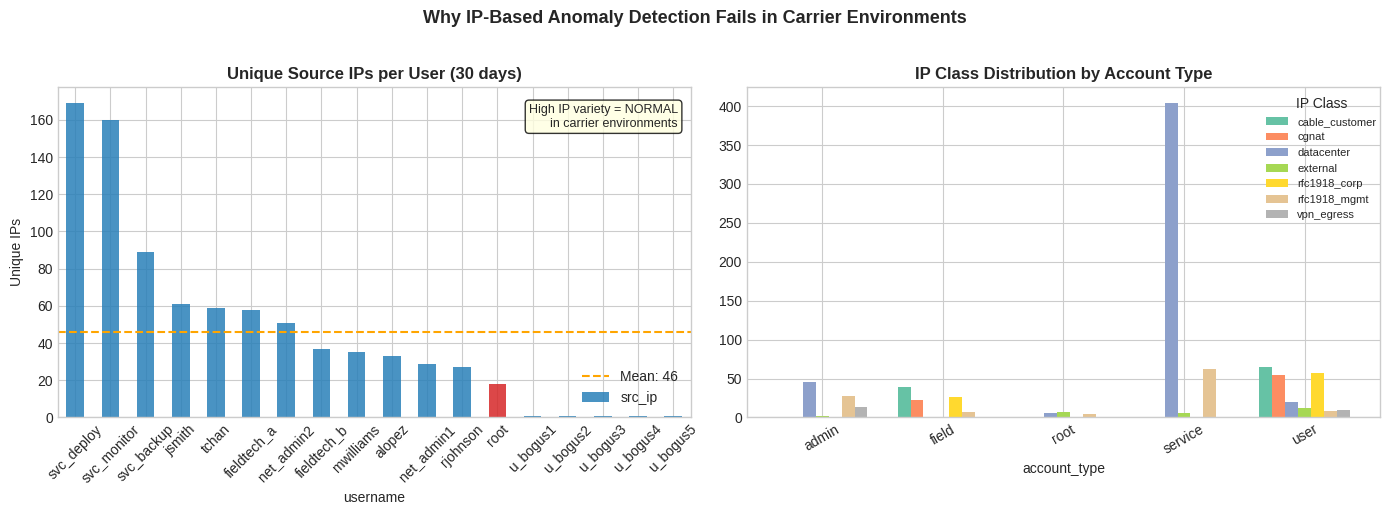

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ip_var = df.groupby('username')['src_ip'].nunique().sort_values(ascending=False)
bar_colors = ['#d62728' if u == 'root' else '#2980b9' for u in ip_var.index]
ip_var.plot(kind='bar', ax=axes[0], color=bar_colors, alpha=0.85)
axes[0].set_title('Unique Source IPs per User (30 days)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Unique IPs')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=ip_var.mean(), color='orange', linestyle='--', label=f'Mean: {ip_var.mean():.0f}')
axes[0].legend()
axes[0].text(0.98, 0.95, 'High IP variety = NORMAL\nin carrier environments',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ip_by_type = df.groupby(['account_type','ip_class']).size().unstack(fill_value=0)
ip_by_type.plot(kind='bar', ax=axes[1], colormap='Set2', width=0.75)
axes[1].set_title('IP Class Distribution by Account Type', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8, title='IP Class', bbox_to_anchor=(1.01,1))

plt.suptitle('Why IP-Based Anomaly Detection Fails in Carrier Environments',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_ip_variance.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Clustering — K-Means & DBSCAN

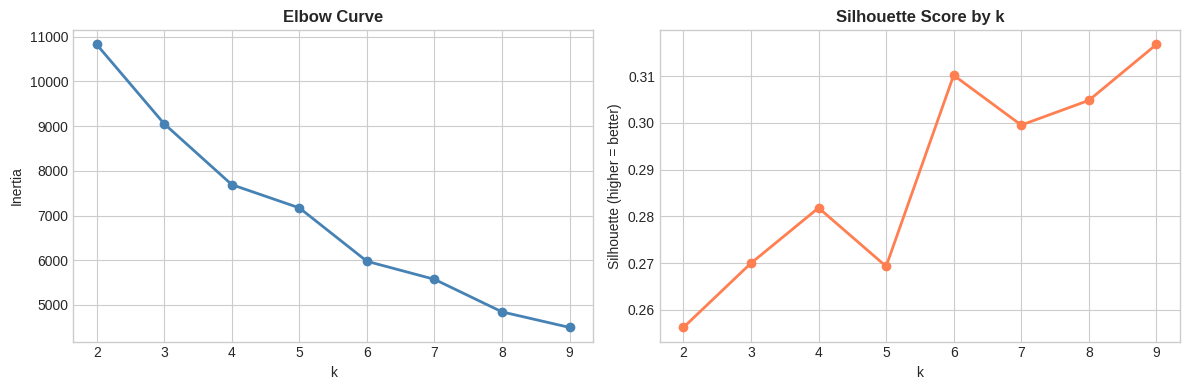

Best k by silhouette: 9


In [27]:
FEATURES = ['acct_risk_score','is_off_hours','is_weekend','hour_sin','hour_cos',
            'is_external_ip','is_datacenter','is_internal','hour_deviation',
            'velocity_10min','user_fail_rate','user_ip_variety',
            'target_mismatch','protocol_enc','success']

X        = df[FEATURES].fillna(0).values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow + silhouette
inertias, silhouettes = [], []
K_range = range(2, 10)
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), silhouettes, 'o-', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score by k', fontsize=12, fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette (higher = better)')
plt.tight_layout()
plt.savefig('02_elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f'Best k by silhouette: {best_k}')

In [28]:
# K-Means final fit
OPTIMAL_K = best_k
km_final  = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['kmeans_cluster'] = km_final.fit_predict(X_scaled)

print(f'K-Means (k={OPTIMAL_K}) cluster sizes:')
print(df['kmeans_cluster'].value_counts().sort_index())
print('\nAnomaly rate per cluster:')
print(df.groupby('kmeans_cluster')['is_anomaly'].mean().round(3).sort_values(ascending=False))

# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
df['dbscan_outlier'] = (df['dbscan_cluster'] == -1).astype(int)

n_out = df['dbscan_outlier'].sum()
print(f'\nDBSCAN outliers: {n_out} ({n_out/len(df)*100:.1f}%)')
print(df.groupby('dbscan_outlier')['is_anomaly'].agg(
    true_anomalies='sum', total='count', anomaly_rate='mean').round(3))

K-Means (k=9) cluster sizes:
kmeans_cluster
0     42
1    193
2     74
3    127
4    141
5     90
6      6
7     29
8    197
Name: count, dtype: int64

Anomaly rate per cluster:
kmeans_cluster
7    1.000
6    1.000
0    0.238
2    0.095
4    0.064
8    0.051
1    0.000
3    0.000
5    0.000
Name: is_anomaly, dtype: float64

DBSCAN outliers: 163 (18.1%)
                true_anomalies  total  anomaly_rate
dbscan_outlier                                     
0                           25    736         0.034
1                           46    163         0.282


## 5. Visualization

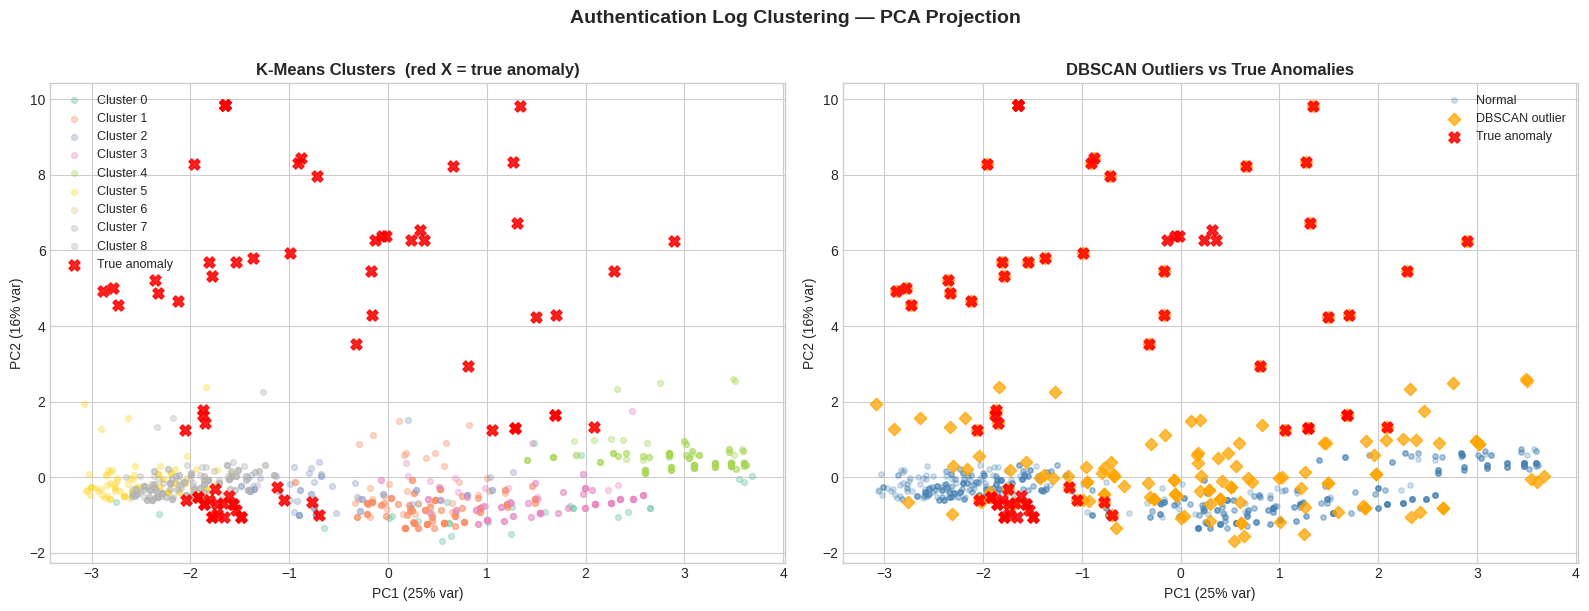

In [30]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca_x'], df['pca_y'] = X_pca[:,0], X_pca[:,1]
ev = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cluster_colors = plt.cm.Set2(np.linspace(0, 1, OPTIMAL_K))
anom = df['is_anomaly'] == 1

for c in range(OPTIMAL_K):
    m = df['kmeans_cluster'] == c
    axes[0].scatter(df.loc[m,'pca_x'], df.loc[m,'pca_y'],
                    c=[cluster_colors[c]], alpha=0.35, s=18, label=f'Cluster {c}')
axes[0].scatter(df.loc[anom,'pca_x'], df.loc[anom,'pca_y'],
                c='red', s=65, marker='X', zorder=5, alpha=0.85, label='True anomaly')
axes[0].set_title('K-Means Clusters  (red X = true anomaly)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({ev[0]*100:.0f}% var)')
axes[0].set_ylabel(f'PC2 ({ev[1]*100:.0f}% var)')
axes[0].legend(fontsize=9)

axes[1].scatter(df.loc[df['dbscan_outlier']==0,'pca_x'], df.loc[df['dbscan_outlier']==0,'pca_y'],
                c='steelblue', alpha=0.25, s=15, label='Normal')
axes[1].scatter(df.loc[df['dbscan_outlier']==1,'pca_x'], df.loc[df['dbscan_outlier']==1,'pca_y'],
                c='orange', alpha=0.75, s=40, marker='D', label='DBSCAN outlier')
axes[1].scatter(df.loc[anom,'pca_x'], df.loc[anom,'pca_y'],
                c='red', s=65, marker='X', zorder=5, alpha=0.85, label='True anomaly')
axes[1].set_title('DBSCAN Outliers vs True Anomalies', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({ev[0]*100:.0f}% var)')
axes[1].set_ylabel(f'PC2 ({ev[1]*100:.0f}% var)')
axes[1].legend(fontsize=9)

plt.suptitle('Authentication Log Clustering — PCA Projection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_cluster_pca.png', dpi=130, bbox_inches='tight')
plt.show()

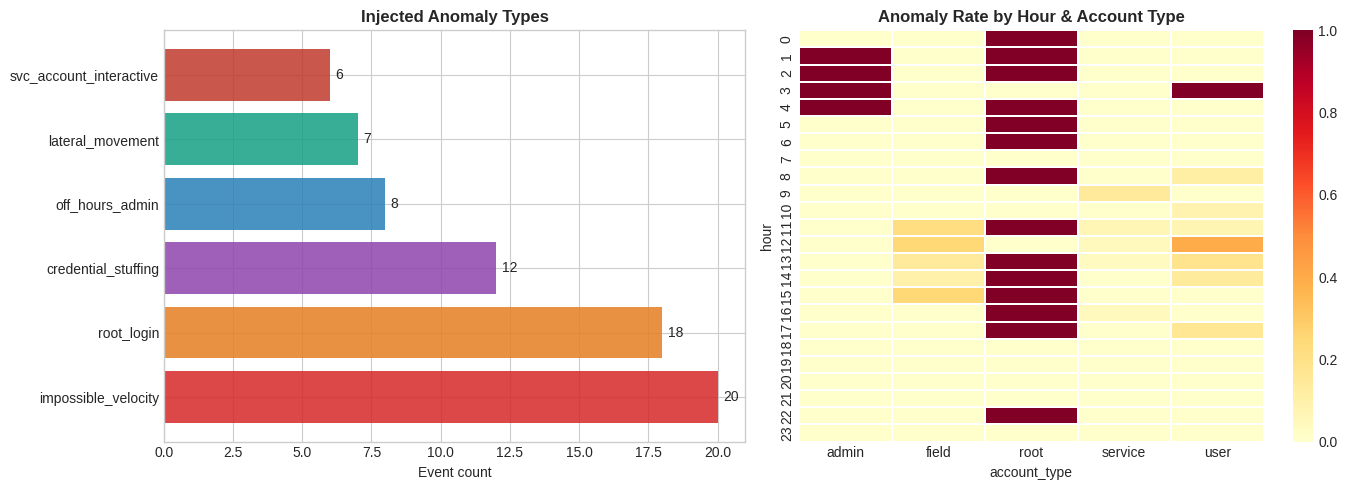

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

anom_df     = df[df['is_anomaly']==1]
type_counts = anom_df['anomaly_type'].value_counts()
bar_cols    = ['#d62728','#e67e22','#8e44ad','#2980b9','#16a085','#c0392b']
axes[0].barh(type_counts.index, type_counts.values, color=bar_cols[:len(type_counts)], alpha=0.85)
axes[0].set_title('Injected Anomaly Types', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Event count')
for i, v in enumerate(type_counts.values):
    axes[0].text(v+0.2, i, str(v), va='center', fontsize=10)

heat = df.groupby(['hour','account_type'])['is_anomaly'].mean().unstack(fill_value=0)
sns.heatmap(heat, ax=axes[1], cmap='YlOrRd', annot=False, linewidths=0.3)
axes[1].set_title('Anomaly Rate by Hour & Account Type', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('04_anomaly_breakdown.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Composite Risk Scoring

In [32]:
def compute_risk(row):
    score, flags = 0.0, []
    if row['username'] == 'root':                                      score += 5.0;  flags.append('ROOT_LOGIN')
    if row['is_off_hours'] and row['acct_risk_score'] >= 3:            score += 3.0;  flags.append('OFF_HOURS_PRIVILEGED')
    if row['is_external_ip'] and row['acct_risk_score'] >= 3:          score += 2.5;  flags.append('EXTERNAL_PRIVILEGED')
    if row['velocity_10min'] >= 8:                                     score += 2.0;  flags.append(f'HIGH_VELOCITY_{int(row["velocity_10min"])}_IN_10MIN')
    if row['target_mismatch']:                                         score += 2.0;  flags.append('SVC_TARGET_MISMATCH')
    if row['dbscan_outlier']:                                          score += 1.5;  flags.append('DBSCAN_OUTLIER')
    if row['is_external_ip'] and not row['success']:                   score += 1.0;  flags.append('EXTERNAL_AUTH_FAILURE')
    if row['hour_deviation'] > 6:                                      score += 1.0;  flags.append(f'HOUR_DEV_{row["hour_deviation"]:.0f}H')
    if row['is_off_hours'] and row['is_weekend']:                      score += 0.75; flags.append('OFF_HOURS_WEEKEND')
    return pd.Series({'risk_score': round(score,2), 'risk_flags': ' | '.join(flags) if flags else 'NONE'})

risk_df = df.apply(compute_risk, axis=1)
df = pd.concat([df, risk_df], axis=1)
df['risk_score_norm'] = (df['risk_score'] / df['risk_score'].max() * 10).round(2)
df['severity'] = df['risk_score_norm'].apply(
    lambda s: 'CRITICAL' if s>=7 else 'HIGH' if s>=4 else 'MEDIUM' if s>=2 else 'LOW' if s>0 else 'INFO')

print('Severity distribution:')
print(df['severity'].value_counts())
print('\nMean risk score — anomalous vs normal:')
print(df.groupby('is_anomaly')['risk_score_norm'].mean().round(2))

Severity distribution:
severity
INFO        518
LOW         335
MEDIUM       24
HIGH         13
CRITICAL      9
Name: count, dtype: int64

Mean risk score — anomalous vs normal:
is_anomaly
0    0.38
1    2.84
Name: risk_score_norm, dtype: float64


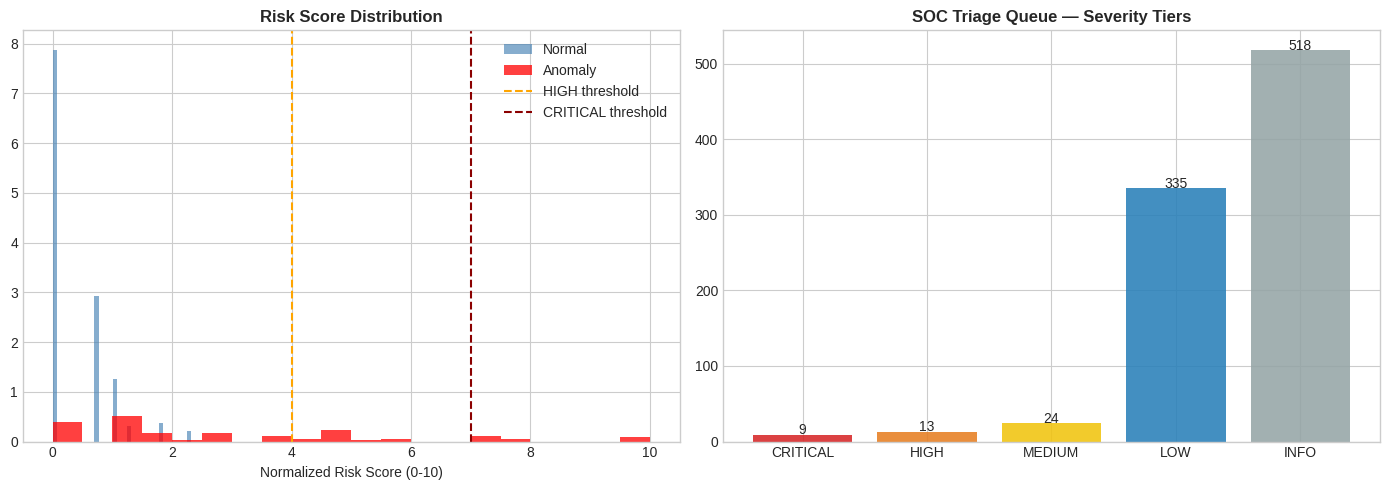

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['is_anomaly']==0]['risk_score_norm'], bins=30, alpha=0.65, color='steelblue', label='Normal', density=True)
axes[0].hist(df[df['is_anomaly']==1]['risk_score_norm'], bins=20, alpha=0.75, color='red',       label='Anomaly', density=True)
axes[0].axvline(x=4, color='orange',  linestyle='--', label='HIGH threshold')
axes[0].axvline(x=7, color='darkred', linestyle='--', label='CRITICAL threshold')
axes[0].set_title('Risk Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Normalized Risk Score (0-10)'); axes[0].legend()

sev_order  = ['CRITICAL','HIGH','MEDIUM','LOW','INFO']
sev_colors = ['#d62728','#e67e22','#f1c40f','#2980b9','#95a5a6']
sev_counts = df['severity'].value_counts().reindex(sev_order, fill_value=0)
bars = axes[1].bar(sev_order, sev_counts.values, color=sev_colors, alpha=0.88)
axes[1].set_title('SOC Triage Queue — Severity Tiers', fontsize=12, fontweight='bold')
for bar, cnt in zip(bars, sev_counts.values):
    if cnt > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(cnt), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('05_risk_scores.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. SOC Alert Output & Detection Performance

In [34]:
alert_cols = ['timestamp','username','account_type','src_ip','ip_class',
              'target','protocol','success','severity','risk_score_norm','risk_flags','anomaly_type']
alerts = (df[df['severity'].isin(['CRITICAL','HIGH'])][alert_cols]
          .sort_values('risk_score_norm', ascending=False).reset_index(drop=True))

print(f'CRITICAL + HIGH alerts : {len(alerts)}')
print(f'True anomalies caught  : {(alerts["anomaly_type"]!="normal").sum()}')
print(f'False positives        : {(alerts["anomaly_type"]=="normal").sum()}')
print()
pd.set_option('display.max_colwidth', 55)
alerts[['timestamp','username','src_ip','ip_class','severity','risk_score_norm','risk_flags']].head(15)

CRITICAL + HIGH alerts : 22
True anomalies caught  : 22
False positives        : 0



,timestamp,username,src_ip,ip_class,severity,risk_score_norm,risk_flags
0,2024-01-01 00:56:00,root,185.220.49.50,external,CRITICAL,10.00,ROOT_LOGIN | OFF_HOURS_PRIVILEGED | EXTERNAL_PRIVIL...
1,2024-01-13 01:30:00,root,185.220.4.100,external,CRITICAL,9.82,ROOT_LOGIN | OFF_HOURS_PRIVILEGED | EXTERNAL_PRIVIL...
2,2024-01-14 04:47:00,root,185.220.13.1,external,CRITICAL,9.82,ROOT_LOGIN | OFF_HOURS_PRIVILEGED | EXTERNAL_PRIVIL...
3,2024-01-11 17:00:00,root,185.220.42.50,external,CRITICAL,7.86,ROOT_LOGIN | EXTERNAL_PRIVILEGED | DBSCAN_OUTLIER |...
4,2024-01-04 02:31:00,root,69.252.97.4,datacenter,CRITICAL,7.50,ROOT_LOGIN | OFF_HOURS_PRIVILEGED | DBSCAN_OUTLIER ...
5,2024-01-06 05:58:00,root,69.252.93.2,datacenter,CRITICAL,7.32,ROOT_LOGIN | OFF_HOURS_PRIVILEGED | DBSCAN_OUTLIER ...
6,2024-01-14 13:12:00,root,185.220.20.100,external,CRITICAL,7.14,ROOT_LOGIN | EXTERNAL_PRIVILEGED | DBSCAN_OUTLIER |...
7,2024-01-25 11:00:00,root,185.220.36.100,external,CRITICAL,7.14,ROOT_LOGIN | EXTERNAL_PRIVILEGED | DBSCAN_OUTLIER |...
8,2024-01-11 14:43:00,root,185.220.49.1,external,CRITICAL,7.14,ROOT_LOGIN | EXTERNAL_PRIVILEGED | DBSCAN_OUTLIER |...
9,2024-01-26 02:54:00,net_admin1,185.220.8.1,external,HIGH,5.71,OFF_HOURS_PRIVILEGED | EXTERNAL_PRIVILEGED | DBSCAN...


In [35]:
root_events = df[df['username']=='root'][[
    'timestamp','src_ip','ip_class','target','protocol','success','severity','risk_score_norm','risk_flags'
]].sort_values('timestamp').reset_index(drop=True)

successful_root = int(root_events['success'].sum())
print(f'Root login attempts : {len(root_events)}')
print(f'Successful root auth: {successful_root}  {"<-- CRITICAL" if successful_root > 0 else "(all blocked)"}')
print()
print(root_events[['timestamp','src_ip','ip_class','target','success','severity','risk_flags']].to_string(index=False))

Root login attempts : 18
Successful root auth: 4  <-- CRITICAL

          timestamp         src_ip     ip_class      target  success severity                                                                                                      risk_flags
2024-01-01 00:56:00  185.220.49.50     external        cmts        0 CRITICAL ROOT_LOGIN | OFF_HOURS_PRIVILEGED | EXTERNAL_PRIVILEGED | DBSCAN_OUTLIER | EXTERNAL_AUTH_FAILURE | HOUR_DEV_11H
2024-01-04 02:31:00    69.252.97.4   datacenter router-core        0 CRITICAL                                                ROOT_LOGIN | OFF_HOURS_PRIVILEGED | DBSCAN_OUTLIER | HOUR_DEV_9H
2024-01-06 05:58:00    69.252.93.2   datacenter        cmts        0 CRITICAL                                          ROOT_LOGIN | OFF_HOURS_PRIVILEGED | DBSCAN_OUTLIER | OFF_HOURS_WEEKEND
2024-01-06 16:47:00    69.252.99.5   datacenter router-core        0     HIGH                                                                                     ROOT_LOGIN | D

In [36]:
true_labels = df['is_anomaly'].values
dbscan_pred = df['dbscan_outlier'].values
score_pred  = df['severity'].isin(['CRITICAL','HIGH']).astype(int).values

print('=' * 58)
print('DETECTION PERFORMANCE SUMMARY')
print('=' * 58)
for name, pred in [('DBSCAN outlier flag      ', dbscan_pred),
                   ('Risk score (HIGH+CRITICAL)', score_pred)]:
    p  = precision_score(true_labels, pred, zero_division=0)
    r  = recall_score(true_labels, pred, zero_division=0)
    f1 = f1_score(true_labels, pred, zero_division=0)
    cm = confusion_matrix(true_labels, pred)
    print(f'\n{name}')
    print(f'  Precision : {p:.3f}   (of flagged events, how many are real?)')
    print(f'  Recall    : {r:.3f}   (of real anomalies, how many caught?)')
    print(f'  F1        : {f1:.3f}')
    print(f'  TN={cm[0,0]:4d}  FP={cm[0,1]:4d}  FN={cm[1,0]:4d}  TP={cm[1,1]:4d}')

print('\nIn security: RECALL > PRECISION. Missing an anomaly costs more than a false positive.')

DETECTION PERFORMANCE SUMMARY

DBSCAN outlier flag      
  Precision : 0.282   (of flagged events, how many are real?)
  Recall    : 0.648   (of real anomalies, how many caught?)
  F1        : 0.393
  TN= 711  FP= 117  FN=  25  TP=  46

Risk score (HIGH+CRITICAL)
  Precision : 1.000   (of flagged events, how many are real?)
  Recall    : 0.310   (of real anomalies, how many caught?)
  F1        : 0.473
  TN= 828  FP=   0  FN=  49  TP=  22

In security: RECALL > PRECISION. Missing an anomaly costs more than a false positive.


In [37]:
alerts.to_csv('alert_queue.csv', index=False)
df.to_csv('full_log_scored.csv', index=False)
print(f'Exported:')
print(f'  alert_queue.csv     — {len(alerts)} CRITICAL/HIGH priority alerts')
print(f'  full_log_scored.csv — {len(df):,} events with risk scores and cluster labels')

Exported:
  alert_queue.csv     — 22 CRITICAL/HIGH priority alerts
  full_log_scored.csv — 899 events with risk scores and cluster labels


## 8. Key Takeaways

### The carrier IP problem
Users in ISP/carrier environments appear across dozens of unique IP addresses — internal RFC1918, CGNAT, cable customer circuits, VPN egress, and datacenter ranges. IP-based anomaly detection generates unmanageable false-positive rates here, and trains analysts to ignore alerts — the worst outcome.

### What behavioral clustering catches instead
- **Root login attempts** — flagged by account type regardless of source IP
- **Impossible velocity** — same user in geographically separated DCs within minutes
- **Credential stuffing** — burst failure pattern across many accounts from one source
- **Off-hours privileged access** — deviation from established user baseline
- **Service account misuse** — protocol and target mismatch
- **Lateral movement** — low-privilege account hitting high-privilege targets

### Next steps for productionization
1. Replace synthetic data with real RADIUS/TACACS log exports
2. Rolling 30-day per-user baseline (Kafka streaming or Spark batch)
3. Tune DBSCAN `eps` / `min_samples` against labeled incident data
4. Add geolocation for precise impossible-travel calculation
5. SIEM integration (Splunk, Microsoft Sentinel) via alert export
6. Transition to supervised learning once labeled incident corpus is available

---
*Author: Eric Maurer | CISSP | Principal IAM & Security Architect*  
*linkedin.com/in/eric-maurer-73ba603b9*